# Data Collecting


In [2]:
import numpy as np
import tensorflow as tf

# Load the MNIST dataset directly from Keras
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Data Train: {x_train.shape}, Label Train: {y_train.shape}")
print(f"Data Test: {x_test.shape}, Label Test: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Data Train: (60000, 28, 28), Label Train: (60000,)
Data Test: (10000, 28, 28), Label Test: (10000,)


Cek bentuk data dulu pakai data pertama (`x_train[0]`), lalu visualisasi

In [3]:
import matplotlib.pyplot as plt

x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

Ga perlu reshape karna udah (28, 28). Lanjut liat visualnya. Ini ga wajib sih, tapi kan penasaran aja ya bentukannya kek mana. Hehe


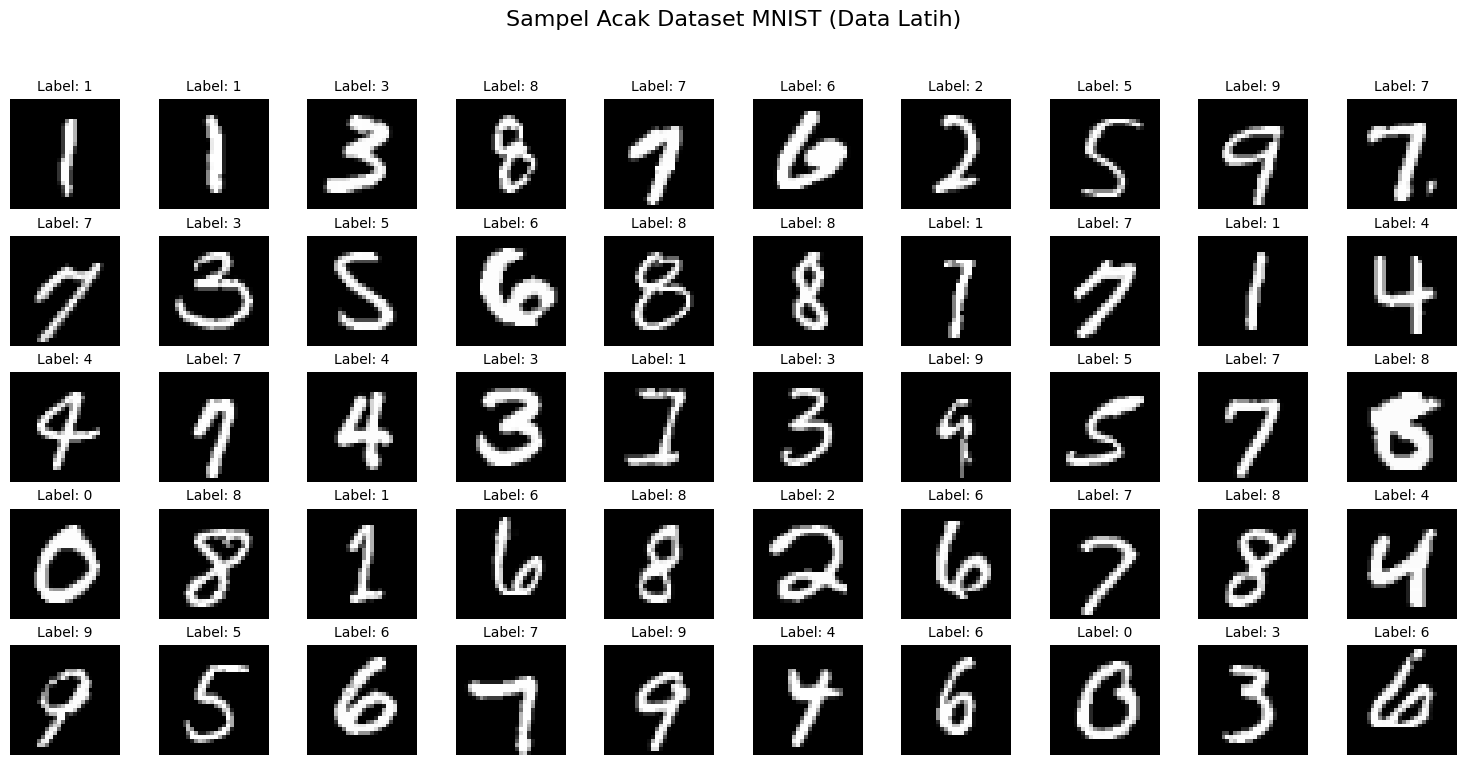

In [ ]:
# Tentukan ukuran grid (misal 5x10 = 50 gambar)
rows = 5
cols = 10
fig, axes = plt.subplots(rows, cols, figsize=(15, 8))

# Ambil indeks acak agar visualisasinya variatif setiap di-run
random_indices = np.random.choice(len(x_train), rows * cols, replace=False)

# Looping untuk nampilin gambar di grid
for i, ax in enumerate(axes.flat):
    idx = random_indices[i]
    ax.imshow(x_train[idx], cmap='gray')
    ax.set_title(f"Label: {y_train[idx]}", fontsize=10)
    ax.axis('off') # Sembunyikan sumbu x dan y

plt.suptitle("Sampel Acak Dataset MNIST (Data Latih)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Atur jarak agar rapi
plt.show()

# HOG
Olah menggunakan HOG dengan step2 berikut
1. Normalisasi dataset
2. Mengubah 60.000 gambar menjadi vektor HOG

### Normalisasi
Komputer melihat warna putih sebagai angka 255 dan hitam sebagai 0. Tapi, angka ratusan itu berat buat dihitung. Jadi, harus dinormalisasi biar cuma ada 0 dan 1 aja

In [ ]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

### Ubah gambar jadi vektor
`hog()` fungsinya nyari garis-garis utama. `orientations=9` artinya kita tanya ke setiap bagian foto, "Garis di sini miring ke mana? Ke atas? Ke samping? Atau serong?". Ada 9 arah yang disediakan.

Datset MNIST itu merupakan gambar berukuran $28 \times 28$ pixel. Kita bagi gambar itu jadi sel $4 \times 4$ (`pixels_per_cell=(4, 4)`).
- Horizontal: $28 \text{ piksel} / 4 = 7 \text{ sel}$.
- Vertikal: $28 \text{ piksel} / 4 = 7 \text{ sel}$.
- Jadi, total ada $7 \times 7 = 49$ sel di seluruh gambar.

Biar hasilnya lebih akurat terhadap perubahan cahaya, HOG menggabungkan sel-sel tadi menjadi blok-blok. `cells_per_block=(2, 2)` artinya satu blok berisi $2 \times 2 = 4$ sel. Blok bergerak seperti *sliding window*.
- Dari 7 sel horizontal, jendela ukuran 2 sel bisa bergeser sebanyak 6 kali.
- Dari 7 sel vertikal, jendela ukuran 2 sel bisa bergeser sebanyak 6 kali.
- Maka, total ada $6 \times 6 = 36$ posisi blok di seluruh gambar.

Di dalam setiap sel, kita menghitung 9 arah garis. Karena 1 blok berisi 4 sel, maka 1 blok punya $4 \text{ sel} \times 9 \text{ arah} = 36 \text{ angka (fitur)}.$ Hasil akhirnya jadi...

$$\text{Total Fitur} = 36 \text{ posisi blok} \times 36 \text{ angka per blok} = \mathbf{1296}.$$

In [ ]:
from skimage.feature import hog

def extract_hog_features(data):
    hog_features = []
    for img in data:
        fd = hog(img, orientations=9, pixels_per_cell=(4, 4),
                 cells_per_block=(2, 2), visualize=False)
        hog_features.append(fd)
    return np.array(hog_features)

#Ekstrak fitur HOG
x_train_hog = extract_hog_features(x_train)
x_test_hog = extract_hog_features(x_test)

print(f"Bentuk data HOG Train: {x_train_hog.shape}")
print(f"Bentuk data HOG Test: {x_test_hog.shape}")

Bentuk data HOG Train: (60000, 1296)
Bentuk data HOG Test: (10000, 1296)


### Kesimpulan
- `x_train`: 60.000 gambar dari dataset buat latihan. Udh dinormalisasi
- `x_test`: 10.000 gambar dari dataset buat diuji. Udh dinormalisasi
- `x_train_hog`: vektor HOG dari 60.000 gambar buat latihan.
- `y_train`: label 0-9 untuk setiap gambar di x_train_hog.
- `x_test_hog`: vektor HOG dari 10.000 gambar buat diuji.
- `y_test`: label 0-9 untuk setiap gambar di x_test_hog.

Yang dipake buat KNN itu 4 variabel terbawah

**Feature Scalling**
Karena KNN berbasis jarak maka skala fitur harus searagm agar hasil tidak bias. Proses normalisasi fitur dilakukan pakai StandarScaler untuk memastikan fitur memiliki distribusi dengan rata-rata nol dan variansi satu, sehingga meningkatkan performa algoritma berbasis jarak seperti KNN:

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_hog = scaler.fit_transform(x_train_hog)
x_test_hog = scaler.transform(x_test_hog)

**Training Model KNN**
Setelah feature scalling digunakanlah KNN di sini menggunakan euclidean distance dengan parameter jumlah tetangga sebesar 3:

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_hog, y_train)

KNeighborsClassifier(n_neighbors=3)

mengukur akurasi model

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = knn.predict(x_test_hog)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9561


Nah untuk nunjukin mana pola kesalahan di model sama kira kira digit maan yang sering salah

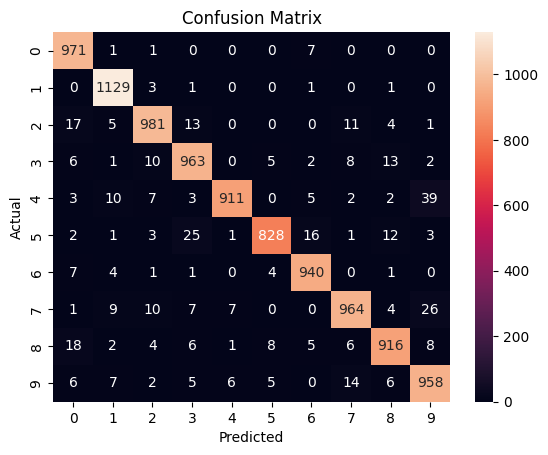

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

grafik di atas nunjukin angka yang sering salah dibaca misalnya pada data aktual itu angka 4 tapi diprediksi bisa dikira angka 1 bahkan paling banyak dibaca angka 9. ini masuk akal soalnya biasanya orang orang nulis angka ini mirip mirip (tergatung gaya penulisan)

In [ ]:
for k in [1, 3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train_hog, y_train)
    acc = knn.score(x_test_hog, y_test)
    print(f"K={k}, Accuracy={acc}")

K=1, Accuracy=0.9481
K=3, Accuracy=0.9561
K=5, Accuracy=0.957
K=7, Accuracy=0.9566


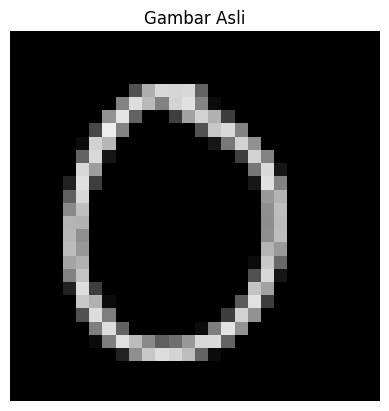

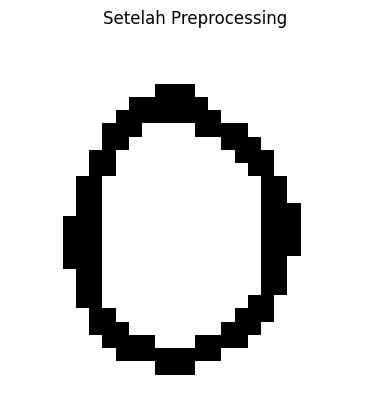

Prediksi Digit: 0
Label Asli: 0
Status: BENAR
Akurasi: 100%


In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from skimage.feature import hog

# =====================
# URL GAMBAR
# =====================
url = "https://raw.githubusercontent.com/rubinibiru/project-knn-hog/main/datatrain-hog-knn/0.png"

# =====================
# LOAD IMAGE
# =====================
resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img = cv2.imdecode(image, cv2.IMREAD_COLOR)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Gambar Asli")
plt.axis('off')
plt.show()

# =====================
# PREPROCESSING (FIXED)
# =====================
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# resize ke standar MNIST
img = cv2.resize(img, (28, 28))

# blur untuk mengurangi noise
img = cv2.GaussianBlur(img, (5,5), 0)

# threshold otomatis (lebih stabil)
_, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# dilation untuk memperjelas bentuk digit
kernel = np.ones((2,2), np.uint8)
img = cv2.dilate(img, kernel, iterations=1)

# normalisasi
img = img / 255.0

# =====================
# CEK HASIL PREPROCESSING
# =====================
plt.imshow(img, cmap='gray')
plt.title("Setelah Preprocessing")
plt.axis('off')
plt.show()

# =====================
# HOG FEATURE
# =====================
hog_feature = hog(img,
                  orientations=9,
                  pixels_per_cell=(4, 4),
                  cells_per_block=(2, 2))

# pastikan shape benar
hog_feature = np.array(hog_feature).reshape(1, -1)

# scaling (HARUS sama dengan training)
hog_feature = scaler.transform(hog_feature)

# =====================
# PREDIKSI
# =====================
prediction = knn.predict(hog_feature)[0]

# label asli (ubah sesuai gambar)
true_label = 0

print("Prediksi Digit:", prediction)
print("Label Asli:", true_label)

# =====================
# HASIL AKURASI (1 DATA)
# =====================
if prediction == true_label:
    print("Status: BENAR")
    print("Akurasi: 100%")
else:
    print("Status: SALAH")
    print("Akurasi: 0%")

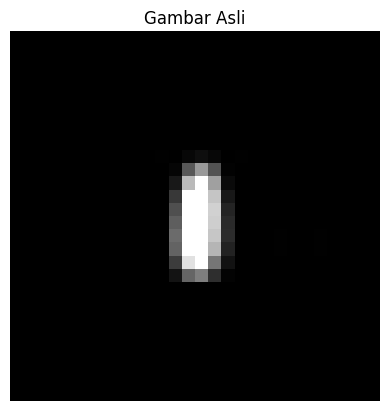

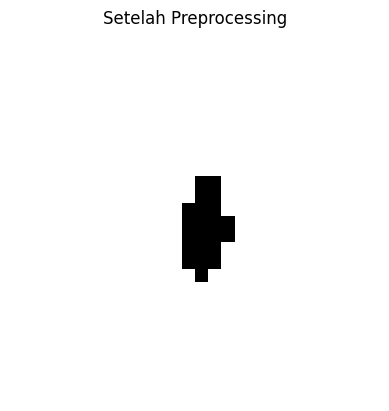

Prediksi Digit: 1
Label Asli: 1
Status: BENAR
Akurasi: 100%


In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from skimage.feature import hog

# =====================
# URL GAMBAR
# =====================
url = "https://raw.githubusercontent.com/rubinibiru/project-knn-hog/main/datatrain-hog-knn/1.jpg"

# =====================
# LOAD IMAGE
# =====================
resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img = cv2.imdecode(image, cv2.IMREAD_COLOR)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Gambar Asli")
plt.axis('off')
plt.show()

# =====================
# PREPROCESSING (FIXED)
# =====================
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# resize ke standar MNIST
img = cv2.resize(img, (28, 28))

# blur untuk mengurangi noise
img = cv2.GaussianBlur(img, (5,5), 0)

# threshold otomatis (lebih stabil)
_, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# dilation untuk memperjelas bentuk digit
kernel = np.ones((2,2), np.uint8)
img = cv2.dilate(img, kernel, iterations=1)

# normalisasi
img = img / 255.0

# =====================
# CEK HASIL PREPROCESSING
# =====================
plt.imshow(img, cmap='gray')
plt.title("Setelah Preprocessing")
plt.axis('off')
plt.show()

# =====================
# HOG FEATURE
# =====================
hog_feature = hog(img,
                  orientations=9,
                  pixels_per_cell=(4, 4),
                  cells_per_block=(2, 2))

# pastikan shape benar
hog_feature = np.array(hog_feature).reshape(1, -1)

# scaling (HARUS sama dengan training)
hog_feature = scaler.transform(hog_feature)

# =====================
# PREDIKSI
# =====================
prediction = knn.predict(hog_feature)[0]

# label asli (ubah sesuai gambar)
true_label = 1

print("Prediksi Digit:", prediction)
print("Label Asli:", true_label)

# =====================
# HASIL AKURASI (1 DATA)
# =====================
if prediction == true_label:
    print("Status: BENAR")
    print("Akurasi: 100%")
else:
    print("Status: SALAH")
    print("Akurasi: 0%")

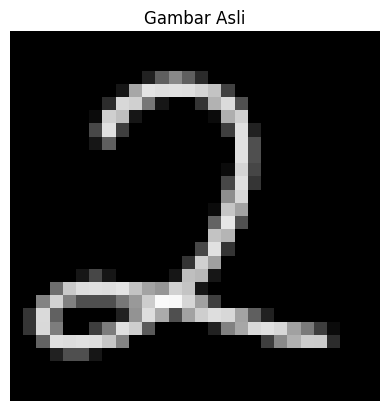

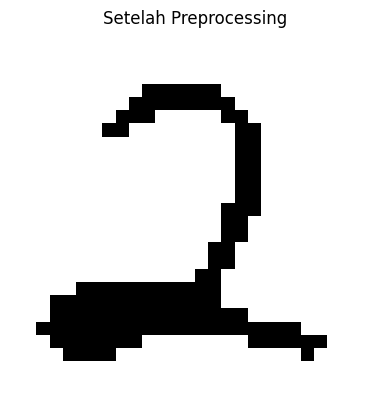

Prediksi Digit: 3
Label Asli: 2
Status: SALAH
Akurasi: 0%


In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from skimage.feature import hog

# =====================
# URL GAMBAR
# =====================
url = "https://raw.githubusercontent.com/rubinibiru/project-knn-hog/main/datatrain-hog-knn/2.png"

# =====================
# LOAD IMAGE
# =====================
resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img = cv2.imdecode(image, cv2.IMREAD_COLOR)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Gambar Asli")
plt.axis('off')
plt.show()

# =====================
# PREPROCESSING (FIXED)
# =====================
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# resize ke standar MNIST
img = cv2.resize(img, (28, 28))

# blur untuk mengurangi noise
img = cv2.GaussianBlur(img, (5,5), 0)

# threshold otomatis (lebih stabil)
_, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# dilation untuk memperjelas bentuk digit
kernel = np.ones((2,2), np.uint8)
img = cv2.dilate(img, kernel, iterations=1)

# normalisasi
img = img / 255.0

# =====================
# CEK HASIL PREPROCESSING
# =====================
plt.imshow(img, cmap='gray')
plt.title("Setelah Preprocessing")
plt.axis('off')
plt.show()

# =====================
# HOG FEATURE
# =====================
hog_feature = hog(img,
                  orientations=9,
                  pixels_per_cell=(4, 4),
                  cells_per_block=(2, 2))

# pastikan shape benar
hog_feature = np.array(hog_feature).reshape(1, -1)

# scaling (HARUS sama dengan training)
hog_feature = scaler.transform(hog_feature)

# =====================
# PREDIKSI
# =====================
prediction = knn.predict(hog_feature)[0]

# label asli (ubah sesuai gambar)
true_label = 2

print("Prediksi Digit:", prediction)
print("Label Asli:", true_label)

# =====================
# HASIL AKURASI (1 DATA)
# =====================
if prediction == true_label:
    print("Status: BENAR")
    print("Akurasi: 100%")
else:
    print("Status: SALAH")
    print("Akurasi: 0%")

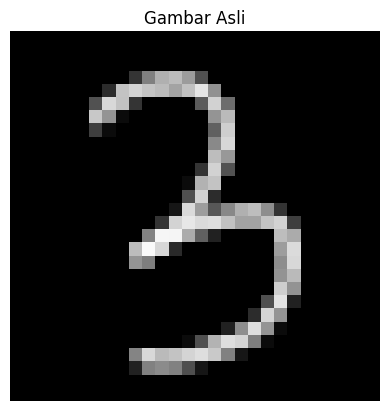

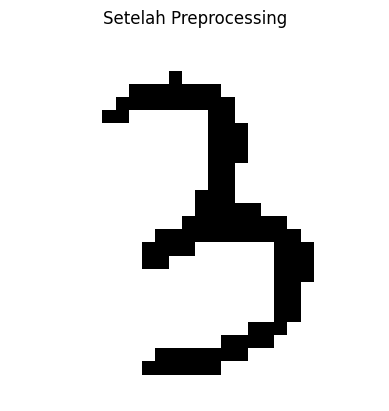

Prediksi Digit: 3
Label Asli: 3
Status: BENAR
Akurasi: 100%


In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from skimage.feature import hog

# =====================
# URL GAMBAR
# =====================
url = "https://raw.githubusercontent.com/rubinibiru/project-knn-hog/main/datatrain-hog-knn/3c.png"

# =====================
# LOAD IMAGE
# =====================
resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img = cv2.imdecode(image, cv2.IMREAD_COLOR)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Gambar Asli")
plt.axis('off')
plt.show()

# =====================
# PREPROCESSING (FIXED)
# =====================
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# resize ke standar MNIST
img = cv2.resize(img, (28, 28))

# blur untuk mengurangi noise
img = cv2.GaussianBlur(img, (5,5), 0)

# threshold otomatis (lebih stabil)
_, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# dilation untuk memperjelas bentuk digit
kernel = np.ones((2,2), np.uint8)
img = cv2.dilate(img, kernel, iterations=1)

# normalisasi
img = img / 255.0

# =====================
# CEK HASIL PREPROCESSING
# =====================
plt.imshow(img, cmap='gray')
plt.title("Setelah Preprocessing")
plt.axis('off')
plt.show()

# =====================
# HOG FEATURE
# =====================
hog_feature = hog(img,
                  orientations=9,
                  pixels_per_cell=(4, 4),
                  cells_per_block=(2, 2))

# pastikan shape benar
hog_feature = np.array(hog_feature).reshape(1, -1)

# scaling (HARUS sama dengan training)
hog_feature = scaler.transform(hog_feature)

# =====================
# PREDIKSI
# =====================
prediction = knn.predict(hog_feature)[0]

# label asli (ubah sesuai gambar)
true_label = 3

print("Prediksi Digit:", prediction)
print("Label Asli:", true_label)

# =====================
# HASIL AKURASI (1 DATA)
# =====================
if prediction == true_label:
    print("Status: BENAR")
    print("Akurasi: 100%")
else:
    print("Status: SALAH")
    print("Akurasi: 0%")

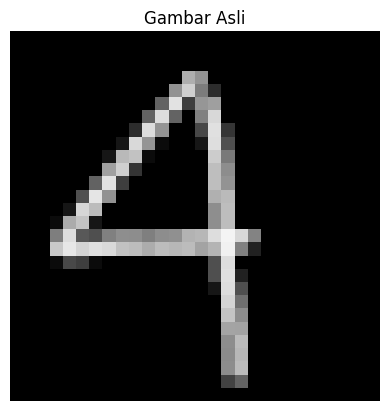

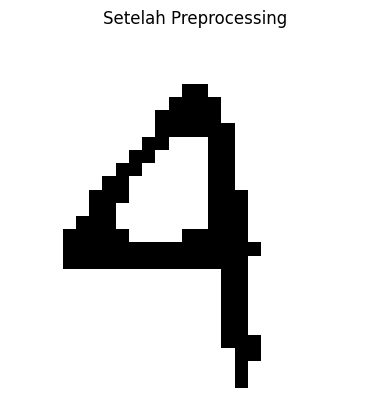

Prediksi Digit: 9
Label Asli: 4
Status: SALAH
Akurasi: 0%


In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from skimage.feature import hog

# =====================
# URL GAMBAR
# =====================
url = "https://raw.githubusercontent.com/rubinibiru/project-knn-hog/main/datatrain-hog-knn/4.png"

# =====================
# LOAD IMAGE
# =====================
resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img = cv2.imdecode(image, cv2.IMREAD_COLOR)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Gambar Asli")
plt.axis('off')
plt.show()

# =====================
# PREPROCESSING (FIXED)
# =====================
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# resize ke standar MNIST
img = cv2.resize(img, (28, 28))

# blur untuk mengurangi noise
img = cv2.GaussianBlur(img, (5,5), 0)

# threshold otomatis (lebih stabil)
_, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# dilation untuk memperjelas bentuk digit
kernel = np.ones((2,2), np.uint8)
img = cv2.dilate(img, kernel, iterations=1)

# normalisasi
img = img / 255.0

# =====================
# CEK HASIL PREPROCESSING
# =====================
plt.imshow(img, cmap='gray')
plt.title("Setelah Preprocessing")
plt.axis('off')
plt.show()

# =====================
# HOG FEATURE
# =====================
hog_feature = hog(img,
                  orientations=9,
                  pixels_per_cell=(4, 4),
                  cells_per_block=(2, 2))

# pastikan shape benar
hog_feature = np.array(hog_feature).reshape(1, -1)

# scaling (HARUS sama dengan training)
hog_feature = scaler.transform(hog_feature)

# =====================
# PREDIKSI
# =====================
prediction = knn.predict(hog_feature)[0]

# label asli (ubah sesuai gambar)
true_label = 4

print("Prediksi Digit:", prediction)
print("Label Asli:", true_label)

# =====================
# HASIL AKURASI (1 DATA)
# =====================
if prediction == true_label:
    print("Status: BENAR")
    print("Akurasi: 100%")
else:
    print("Status: SALAH")
    print("Akurasi: 0%")

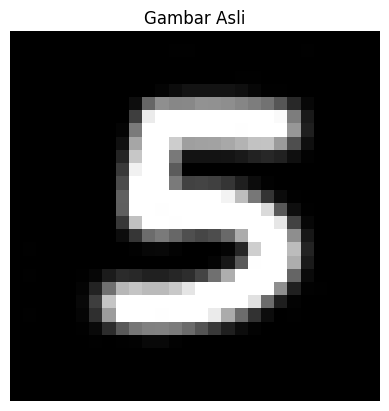

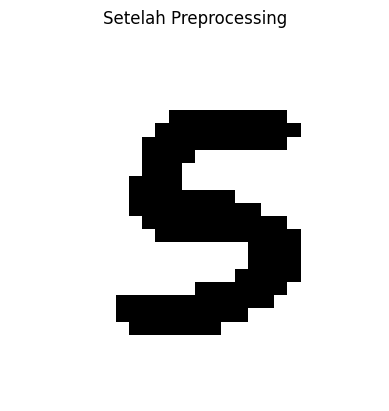

Prediksi Digit: 5
Label Asli: 5
Status: BENAR
Akurasi: 100%


In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from skimage.feature import hog

# =====================
# URL GAMBAR
# =====================
url = "https://raw.githubusercontent.com/rubinibiru/project-knn-hog/main/datatrain-hog-knn/5a.jpg"

# =====================
# LOAD IMAGE
# =====================
resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img = cv2.imdecode(image, cv2.IMREAD_COLOR)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Gambar Asli")
plt.axis('off')
plt.show()

# =====================
# PREPROCESSING (FIXED)
# =====================
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# resize ke standar MNIST
img = cv2.resize(img, (28, 28))

# blur untuk mengurangi noise
img = cv2.GaussianBlur(img, (5,5), 0)

# threshold otomatis (lebih stabil)
_, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# dilation untuk memperjelas bentuk digit
kernel = np.ones((2,2), np.uint8)
img = cv2.dilate(img, kernel, iterations=1)

# normalisasi
img = img / 255.0

# =====================
# CEK HASIL PREPROCESSING
# =====================
plt.imshow(img, cmap='gray')
plt.title("Setelah Preprocessing")
plt.axis('off')
plt.show()

# =====================
# HOG FEATURE
# =====================
hog_feature = hog(img,
                  orientations=9,
                  pixels_per_cell=(4, 4),
                  cells_per_block=(2, 2))

# pastikan shape benar
hog_feature = np.array(hog_feature).reshape(1, -1)

# scaling (HARUS sama dengan training)
hog_feature = scaler.transform(hog_feature)

# =====================
# PREDIKSI
# =====================
prediction = knn.predict(hog_feature)[0]

# label asli (ubah sesuai gambar)
true_label = 5

print("Prediksi Digit:", prediction)
print("Label Asli:", true_label)

# =====================
# HASIL AKURASI (1 DATA)
# =====================
if prediction == true_label:
    print("Status: BENAR")
    print("Akurasi: 100%")
else:
    print("Status: SALAH")
    print("Akurasi: 0%")

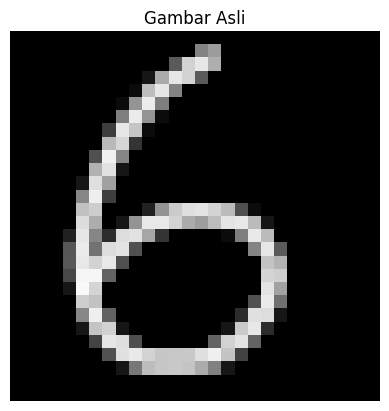

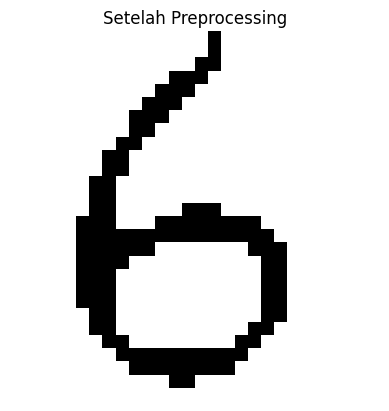

Prediksi Digit: 6
Label Asli: 6
Status: BENAR
Akurasi: 100%


In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from skimage.feature import hog

# =====================
# URL GAMBAR
# =====================
url = "https://raw.githubusercontent.com/rubinibiru/project-knn-hog/main/datatrain-hog-knn/6a.png"

# =====================
# LOAD IMAGE
# =====================
resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img = cv2.imdecode(image, cv2.IMREAD_COLOR)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Gambar Asli")
plt.axis('off')
plt.show()

# =====================
# PREPROCESSING (FIXED)
# =====================
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# resize ke standar MNIST
img = cv2.resize(img, (28, 28))

# blur untuk mengurangi noise
img = cv2.GaussianBlur(img, (5,5), 0)

# threshold otomatis (lebih stabil)
_, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# dilation untuk memperjelas bentuk digit
kernel = np.ones((2,2), np.uint8)
img = cv2.dilate(img, kernel, iterations=1)

# normalisasi
img = img / 255.0

# =====================
# CEK HASIL PREPROCESSING
# =====================
plt.imshow(img, cmap='gray')
plt.title("Setelah Preprocessing")
plt.axis('off')
plt.show()

# =====================
# HOG FEATURE
# =====================
hog_feature = hog(img,
                  orientations=9,
                  pixels_per_cell=(4, 4),
                  cells_per_block=(2, 2))

# pastikan shape benar
hog_feature = np.array(hog_feature).reshape(1, -1)

# scaling (HARUS sama dengan training)
hog_feature = scaler.transform(hog_feature)

# =====================
# PREDIKSI
# =====================
prediction = knn.predict(hog_feature)[0]

# label asli (ubah sesuai gambar)
true_label = 6

print("Prediksi Digit:", prediction)
print("Label Asli:", true_label)

# =====================
# HASIL AKURASI (1 DATA)
# =====================
if prediction == true_label:
    print("Status: BENAR")
    print("Akurasi: 100%")
else:
    print("Status: SALAH")
    print("Akurasi: 0%")

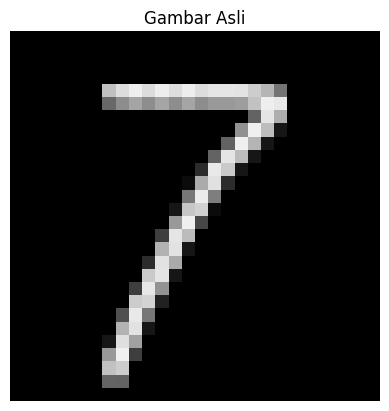

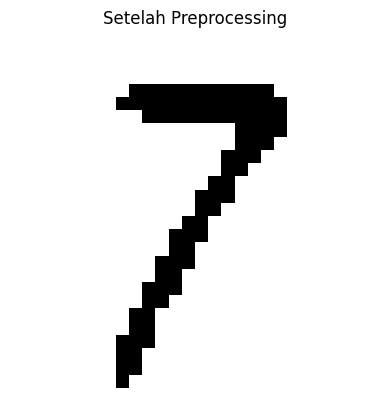

Prediksi Digit: 1
Label Asli: 7
Status: SALAH
Akurasi: 0%


In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from skimage.feature import hog

# =====================
# URL GAMBAR
# =====================
url = "https://raw.githubusercontent.com/rubinibiru/project-knn-hog/main/datatrain-hog-knn/7a.png"

# =====================
# LOAD IMAGE
# =====================
resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img = cv2.imdecode(image, cv2.IMREAD_COLOR)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Gambar Asli")
plt.axis('off')
plt.show()

# =====================
# PREPROCESSING (FIXED)
# =====================
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# resize ke standar MNIST
img = cv2.resize(img, (28, 28))

# blur untuk mengurangi noise
img = cv2.GaussianBlur(img, (5,5), 0)

# threshold otomatis (lebih stabil)
_, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# dilation untuk memperjelas bentuk digit
kernel = np.ones((2,2), np.uint8)
img = cv2.dilate(img, kernel, iterations=1)

# normalisasi
img = img / 255.0

# =====================
# CEK HASIL PREPROCESSING
# =====================
plt.imshow(img, cmap='gray')
plt.title("Setelah Preprocessing")
plt.axis('off')
plt.show()

# =====================
# HOG FEATURE
# =====================
hog_feature = hog(img,
                  orientations=9,
                  pixels_per_cell=(4, 4),
                  cells_per_block=(2, 2))

# pastikan shape benar
hog_feature = np.array(hog_feature).reshape(1, -1)

# scaling (HARUS sama dengan training)
hog_feature = scaler.transform(hog_feature)

# =====================
# PREDIKSI
# =====================
prediction = knn.predict(hog_feature)[0]

# label asli (ubah sesuai gambar)
true_label = 7

print("Prediksi Digit:", prediction)
print("Label Asli:", true_label)

# =====================
# HASIL AKURASI (1 DATA)
# =====================
if prediction == true_label:
    print("Status: BENAR")
    print("Akurasi: 100%")
else:
    print("Status: SALAH")
    print("Akurasi: 0%")

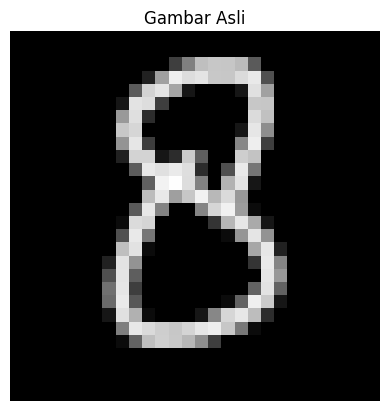

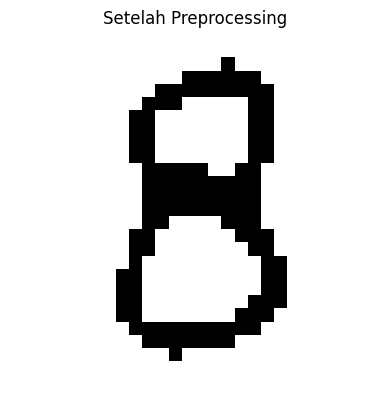

Prediksi Digit: 8
Label Asli: 8
Status: BENAR
Akurasi: 100%


In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from skimage.feature import hog

# =====================
# URL GAMBAR
# =====================
url = "https://raw.githubusercontent.com/rubinibiru/project-knn-hog/main/datatrain-hog-knn/8.png"

# =====================
# LOAD IMAGE
# =====================
resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img = cv2.imdecode(image, cv2.IMREAD_COLOR)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Gambar Asli")
plt.axis('off')
plt.show()

# =====================
# PREPROCESSING (FIXED)
# =====================
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# resize ke standar MNIST
img = cv2.resize(img, (28, 28))

# blur untuk mengurangi noise
img = cv2.GaussianBlur(img, (5,5), 0)

# threshold otomatis (lebih stabil)
_, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# dilation untuk memperjelas bentuk digit
kernel = np.ones((2,2), np.uint8)
img = cv2.dilate(img, kernel, iterations=1)

# normalisasi
img = img / 255.0

# =====================
# CEK HASIL PREPROCESSING
# =====================
plt.imshow(img, cmap='gray')
plt.title("Setelah Preprocessing")
plt.axis('off')
plt.show()

# =====================
# HOG FEATURE
# =====================
hog_feature = hog(img,
                  orientations=9,
                  pixels_per_cell=(4, 4),
                  cells_per_block=(2, 2))

# pastikan shape benar
hog_feature = np.array(hog_feature).reshape(1, -1)

# scaling (HARUS sama dengan training)
hog_feature = scaler.transform(hog_feature)

# =====================
# PREDIKSI
# =====================
prediction = knn.predict(hog_feature)[0]

# label asli (ubah sesuai gambar)
true_label = 8

print("Prediksi Digit:", prediction)
print("Label Asli:", true_label)

# =====================
# HASIL AKURASI (1 DATA)
# =====================
if prediction == true_label:
    print("Status: BENAR")
    print("Akurasi: 100%")
else:
    print("Status: SALAH")
    print("Akurasi: 0%")

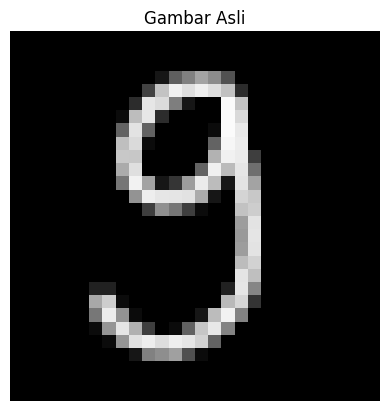

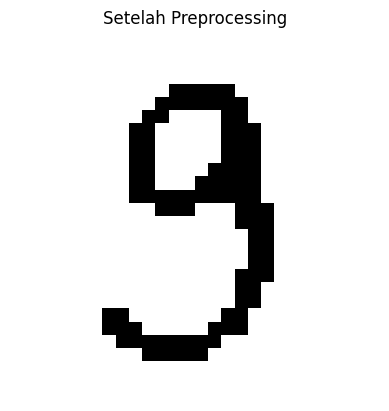

Prediksi Digit: 1
Label Asli: 9
Status: SALAH
Akurasi: 0%


In [ ]:
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
from skimage.feature import hog

# =====================
# URL GAMBAR
# =====================
url = "https://raw.githubusercontent.com/rubinibiru/project-knn-hog/main/datatrain-hog-knn/9c.png"

# =====================
# LOAD IMAGE
# =====================
resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img = cv2.imdecode(image, cv2.IMREAD_COLOR)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Gambar Asli")
plt.axis('off')
plt.show()

# =====================
# PREPROCESSING (FIXED)
# =====================
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# resize ke standar MNIST
img = cv2.resize(img, (28, 28))

# blur untuk mengurangi noise
img = cv2.GaussianBlur(img, (5,5), 0)

# threshold otomatis (lebih stabil)
_, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# dilation untuk memperjelas bentuk digit
kernel = np.ones((2,2), np.uint8)
img = cv2.dilate(img, kernel, iterations=1)

# normalisasi
img = img / 255.0

# =====================
# CEK HASIL PREPROCESSING
# =====================
plt.imshow(img, cmap='gray')
plt.title("Setelah Preprocessing")
plt.axis('off')
plt.show()

# =====================
# HOG FEATURE
# =====================
hog_feature = hog(img,
                  orientations=9,
                  pixels_per_cell=(4, 4),
                  cells_per_block=(2, 2))

# pastikan shape benar
hog_feature = np.array(hog_feature).reshape(1, -1)

# scaling (HARUS sama dengan training)
hog_feature = scaler.transform(hog_feature)

# =====================
# PREDIKSI
# =====================
prediction = knn.predict(hog_feature)[0]

# label asli (ubah sesuai gambar)
true_label = 9

print("Prediksi Digit:", prediction)
print("Label Asli:", true_label)

# =====================
# HASIL AKURASI (1 DATA)
# =====================
if prediction == true_label:
    print("Status: BENAR")
    print("Akurasi: 100%")
else:
    print("Status: SALAH")
    print("Akurasi: 0%")